<a href="https://colab.research.google.com/github/ariqnurcahyo/smart_cane/blob/main/langsung_pake2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
%rm -rf darknet

/content


In [2]:
# Clone versi resmi yang cocok untuk Colab
!git clone https://github.com/AlexeyAB/darknet.git
%cd darknet

# Aktifkan GPU, CUDNN, dan OpenCV di Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/LIBSO=0/LIBSO=1/' Makefile

# Compile
!make

Cloning into 'darknet'...
remote: Enumerating objects: 15900, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 15900 (delta 23), reused 11 (delta 11), pack-reused 15860 (from 3)
Receiving objects: 100% (15900/15900), 14.51 MiB | 7.38 MiB/s, done.
Resolving deltas: 100% (10694/10694), done.
/content/darknet
mkdir -p ./obj/
mkdir -p backup
mkdir -p results
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -fPIC -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: v

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp /content/drive/MyDrive/file_weight/custom-yolov4-tiny-detector_best.weights /content/

<IPython.core.display.Javascript object>

✅ Foto disimpan ke camera_capture.jpg


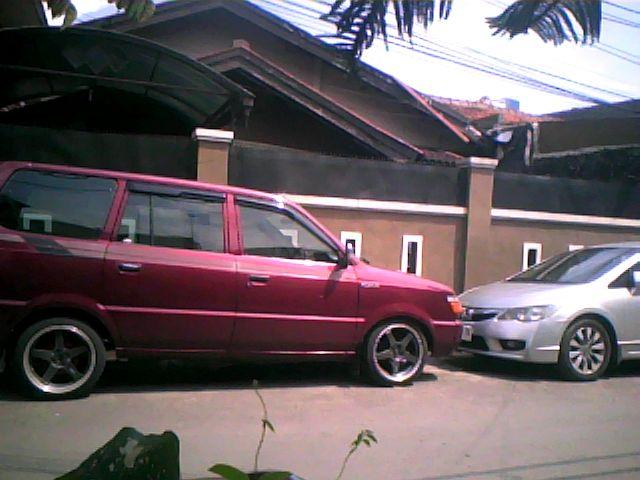

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
   layer   filters  size/strd(dil)      input                output
   0 conv     32       3 x 3/ 2    416 x 416 x   3 ->  208 x 208 x  32 0.075 BF
   1 conv     64       3 x 3/ 2    208 x 208 x  32 ->  104 x 104 x  64 0.399 BF
   2 conv     64       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.797 BF
   3 route  2 		                       1/2 ->  104 x 104 x  32 
   4 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   5 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   6 route  5 4 	                           ->  104 x 104 x  64 
   7 conv     64       1 x 1/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.089 BF
   8 route  2 7 	                           ->  104 x 104 x 128 
   9 max                2x 2/ 2    104 x 104 x 128 ->   52 x  52 x 128 0.001 BF
  10 conv    128   

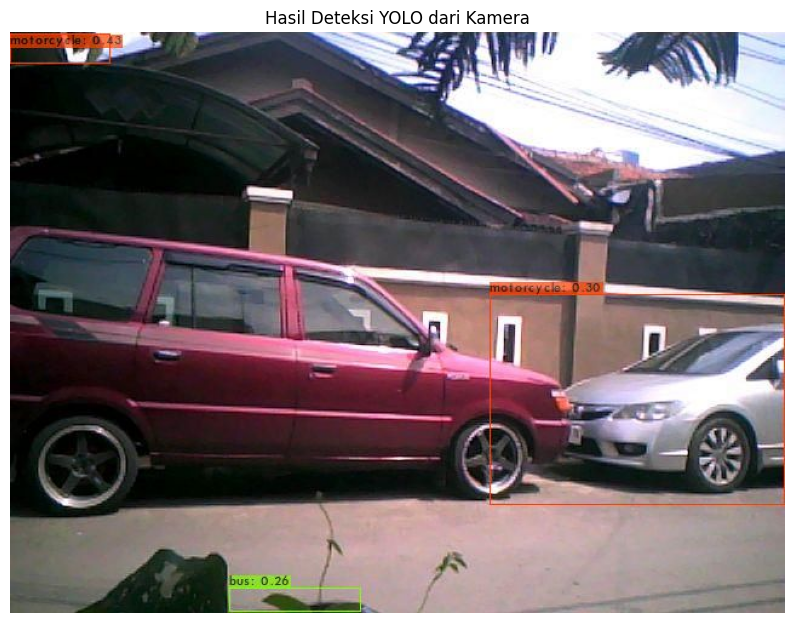

📝 Terdeteksi objek: bus, motorcycle


In [10]:
# Instalasi modul jika belum tersedia
!pip install gTTS -q

# Import libraries
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import PIL
import io
import base64
import matplotlib.pyplot as plt
from gtts import gTTS
import IPython.display as ipd
import os
import re

# Fungsi untuk mengambil gambar dari kamera
def take_photo(filename='camera_capture.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Ambil Foto';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = io.BytesIO(base64.b64decode(data.split(',')[1]))
    img = PIL.Image.open(binary)
    img.save(filename)
    print(f'✅ Foto disimpan ke {filename}')
    return filename

# Langkah 1: Ambil foto dari kamera
filename = take_photo()

# Langkah 2: Tampilkan foto asli
img = cv2.imread(filename)
cv2_imshow(img)

# Langkah 3: Jalankan YOLOv4-tiny untuk deteksi objek
!./darknet detector test /content/drive/MyDrive/file_weight/obj.data \
/content/drive/MyDrive/file_weight/yolov4-tiny-custom.cfg \
/content/drive/MyDrive/file_weight/custom-yolov4-tiny-detector_best.weights \
"{filename}" -dont_show > output.txt

# Langkah 4: Tampilkan hasil deteksi jika ada
if os.path.exists("predictions.jpg"):
    pred_img = cv2.imread('predictions.jpg')
    pred_img_rgb = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(pred_img_rgb)
    plt.axis('off')
    plt.title('Hasil Deteksi YOLO dari Kamera')
    plt.show()
else:
    print("❌ File hasil deteksi (predictions.jpg) tidak ditemukan.")

# Langkah 5: Ambil hasil deteksi dari output.txt
with open("output.txt", "r") as f:
    output = f.read()

# Cari label objek seperti "person: 98%"
labels = re.findall(r'(\w+):\s*\d+%', output)
unique_labels = list(set(labels))

# Langkah 6: Buat deskripsi hasil
if unique_labels:
    description = f"Terdeteksi objek: {', '.join(unique_labels)}"
else:
    description = "Tidak terdeteksi objek apa pun."

print(f'📝 {description}')

# Langkah 7: Ubah teks jadi suara
tts = gTTS(description, lang='id')
tts.save("hasil_deteksi.mp3")

# Langkah 8: Putar suara
ipd.display(ipd.Audio("hasil_deteksi.mp3"))

Saving WhatsApp Image 2025-05-06 at 21.09.56_1fe3b820.jpg to WhatsApp Image 2025-05-06 at 21.09.56_1fe3b820.jpg
✅ Gambar diupload: WhatsApp Image 2025-05-06 at 21.09.56_1fe3b820.jpg


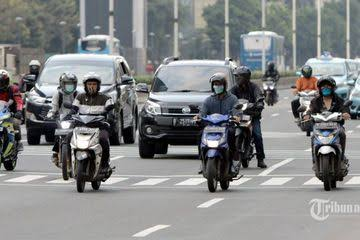

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 2    416 x 416 x   3 ->  208 x 208 x  32 0.075 BF
   1 conv     64       3 x 3/ 2    208 x 208 x  32 ->  104 x 104 x  64 0.399 BF
   2 conv     64       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.797 BF
   3 route  2 		                       1/2 ->  104 x 104 x  32 
   4 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   5 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   6 route  5 4 	                           ->  104 x 104 x  64 
   7 conv     64       1 x 1/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.089 BF
   8 route  2 7 	   

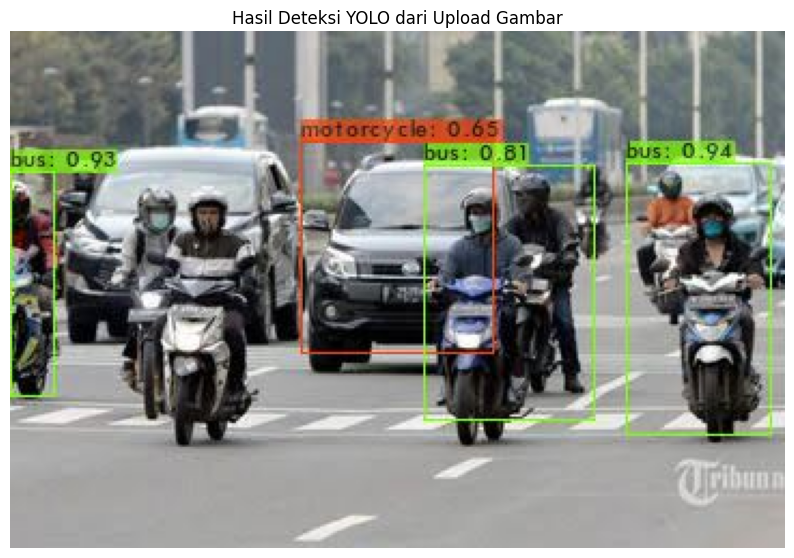

In [ ]:
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Langkah 1: Upload file gambar dari PC
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]
print(f'✅ Gambar diupload: {filename}')

# Langkah 2: Tampilkan gambar yang diupload
img = cv2.imread(filename)
cv2_imshow(img)

# Langkah 3: Jalankan YOLO untuk deteksi objek
!./darknet detector test /content/drive/MyDrive/file_weight/obj.data \
/content/drive/MyDrive/file_weight/yolov4-tiny-custom.cfg \
/content/drive/MyDrive/file_weight/custom-yolov4-tiny-detector_best.weights \
"{filename}" -dont_show

# Langkah 4: Tampilkan hasil deteksi (predictions.jpg)
pred_img = cv2.imread('predictions.jpg')
pred_img_rgb = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(pred_img_rgb)
plt.axis('off')
plt.title('Hasil Deteksi YOLO dari Upload Gambar')
plt.show()

Saving WhatsApp Image 2025-05-06 at 21.09.56_1fe3b820.jpg to WhatsApp Image 2025-05-06 at 21.09.56_1fe3b820 (11).jpg
✅ Gambar diupload: WhatsApp Image 2025-05-06 at 21.09.56_1fe3b820 (11).jpg


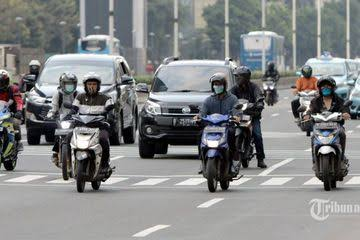

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
   layer   filters  size/strd(dil)      input                output
   0 conv     32       3 x 3/ 2    416 x 416 x   3 ->  208 x 208 x  32 0.075 BF
   1 conv     64       3 x 3/ 2    208 x 208 x  32 ->  104 x 104 x  64 0.399 BF
   2 conv     64       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.797 BF
   3 route  2 		                       1/2 ->  104 x 104 x  32 
   4 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   5 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   6 route  5 4 	                           ->  104 x 104 x  64 
   7 conv     64       1 x 1/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.089 BF
   8 route  2 7 	                           ->  104 x 104 x 128 
   9 max                2x 2/ 2    104 x 104 x 128 ->   52 x  52 x 128 0.001 BF
  10 conv    128   

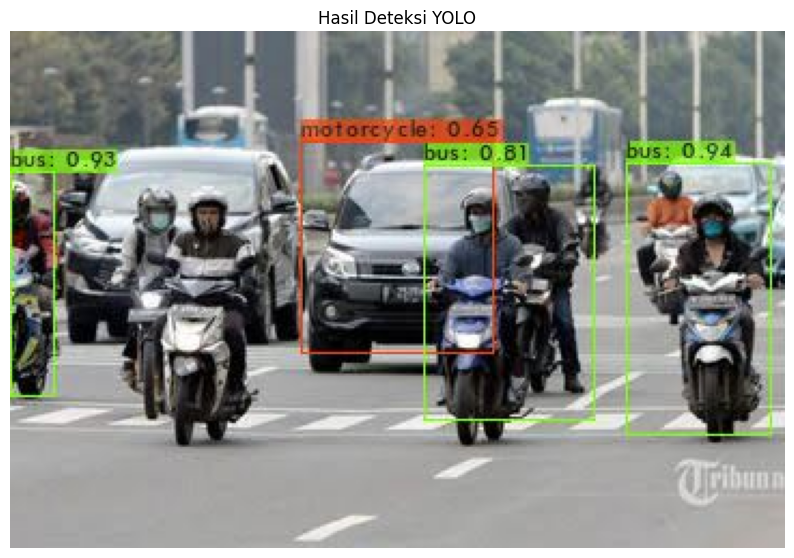

📝 Terdeteksi objek: bus, motorcycle


In [ ]:
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from gtts import gTTS
import IPython.display as ipd
import os
import re

# Upload gambar
uploaded = files.upload()
for filename in uploaded.keys():
    print(f'✅ Gambar diupload: {filename}')

# Tampilkan gambar asli
img = cv2.imread(filename)
cv2_imshow(img)

# Jalankan YOLO deteksi objek
!./darknet detector test /content/drive/MyDrive/file_weight/obj.data \
/content/drive/MyDrive/file_weight/yolov4-tiny-custom.cfg \
/content/drive/MyDrive/file_weight/custom-yolov4-tiny-detector_best.weights \
"{filename}" -dont_show > output.txt

# Tampilkan hasil deteksi gambar
if os.path.exists("predictions.jpg"):
    pred_img = cv2.imread('predictions.jpg')
    pred_img_rgb = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(pred_img_rgb)
    plt.axis('off')
    plt.title('Hasil Deteksi YOLO')
    plt.show()
else:
    print("❌ File hasil deteksi (predictions.jpg) tidak ditemukan.")

# Ambil hasil deteksi dari output.txt
with open("output.txt", "r") as f:
    output = f.read()

# Ambil label seperti: "person: 98%" dll
labels = re.findall(r'(\w+):\s*\d+%', output)
unique_labels = list(set(labels))  # Hilangkan duplikat

# Deskripsi hasil deteksi
if unique_labels:
    description = f"Terdeteksi objek: {', '.join(unique_labels)}"
else:
    description = "Tidak terdeteksi objek apa pun."

print(f'📝 {description}')

# Konversi teks ke suara
tts = gTTS(description, lang='id')
tts.save("hasil_deteksi.mp3")

# Gunakan IPython untuk memutar suara otomatis
ipd.display(ipd.Audio("hasil_deteksi.mp3"))